# Simulate a sky background with realistic background galaxies and Milky Way stars

This notebook shows how to generate a sky background model including background galaxies and MW stars. You are encouraged to use the script at `rosesim/scripts/sim_sky.py`. 

In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
# sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm
import copy
import galsim
import roman_datamodels as rdm
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.image import inject_sources_into_l2
from romanisim.l3 import inject_sources_into_l3

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


## 1. Load JAGUAR background galaxies. 

JAGUAR is a simulated galaxy catalog, designed for JWST work. See here for more details: https://fenrir.as.arizona.edu/jaguar/download_jaguar_files.html

The catalog needs to be requested from that website. You can email me if you really want to use this catalog. 

In [3]:
# cat_Q = Table.read("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_Q_mock_r1_v1.2.fits")
# cat_SF = Table.read("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_SF_mock_r1_v1.2.fits")
# cat_all = vstack([cat_Q, cat_SF])
# cat_all = cat_all[(cat_all['sersic_n'] < 6) & (cat_all['sersic_n'] > 0.35)]
# cat_all.write('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_all_mock_r1_v1.2.fits')

In [35]:
# For Yilun LRD
sim_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/JAGUAR/JADES_all_mock_r1_v1.2.fits')
bandpasses = ['F106', 'F129', 'F158']
# Match cosmos filters to roman filters
print('Warning -- need to figure out the coefficients between JWST and Roman filters.')
for opt_elem in bandpasses:
    if opt_elem == "F062":
        sim_cat['FLUX_F062'] = sim_cat['HST_F606W_fnu'] * 1e-9 / 3631 # convert from nJy to maggies
    elif opt_elem == "F087":
        sim_cat['FLUX_F087'] = sim_cat['HST_F814W_fnu'] * 1e-9 / 3631
    elif opt_elem == "F106":
        F115W = -2.5 * np.log10(sim_cat['NRC_F115W_fnu'] * 1e-9 / 3631)
        F150W = -2.5 * np.log10(sim_cat['NRC_F150W_fnu'] * 1e-9 / 3631)
        Y106 = F115W + (F115W - F150W) * (0.3510699) + 0.00826781 # based on simple SSP, scatter < 0.004 mag
        sim_cat['MAG_F106'] = Y106 #10**(-0.4 * Y106)
    elif opt_elem == "F129":
        F115W = -2.5 * np.log10(sim_cat['NRC_F115W_fnu'] * 1e-9 / 3631)
        F150W = -2.5 * np.log10(sim_cat['NRC_F150W_fnu'] * 1e-9 / 3631)
        J129 = F115W + (F115W - F150W) * (-0.42427082) + -0.05232558 # based on simple SSP, scatter < 0.002 mag
        sim_cat['MAG_F129'] = J129 #10**(-0.4 * J129)
    elif opt_elem == "F146":
        F115W = -2.5 * np.log10(sim_cat['NRC_F115W_fnu'] * 1e-9 / 3631)
        F150W = -2.5 * np.log10(sim_cat['NRC_F150W_fnu'] * 1e-9 / 3631)
        W146 = F150W + (F115W - F150W) * (0.27329887) + -0.03628754 # based on simple SSP, scatter < 0.004 mag
        sim_cat['FLUX_F146'] = 10**(-0.4 * W146)
    elif opt_elem == "F158":
        F115W = -2.5 * np.log10(sim_cat['NRC_F115W_fnu'] * 1e-9 / 3631)
        F150W = -2.5 * np.log10(sim_cat['NRC_F150W_fnu'] * 1e-9 / 3631)
        F277W = -2.5 * np.log10(sim_cat['NRC_F277W_fnu'] * 1e-9 / 3631)
        # [-0.45429239 -0.45096737]
        H158 = F150W + (F115W - F277W) * -0.4543 - 0.451
        # H158 = F150W + (F115W - F150W) * (-0.23109312) + -0.11065068 # based on simple SSP, scatter < 0.002 mag
        sim_cat['MAG_F158'] = H158 #10**(-0.4 * H158)
    elif opt_elem == "F184":
        sim_cat['FLUX_F184'] = sim_cat['NRC_F200W_fnu'] * 1e-9 / 3631
    elif opt_elem == "F213":
        sim_cat['FLUX_F213'] = sim_cat['NRC_F200W_fnu'] * 1e-9 / 3631
    else:
        print(f'Unknown filter {opt_elem} skipped in object catalog creation.')
sim_cat.write('/tigress/jiaxuanl/public_html/RIPPLES/JAGUAR_all_mock_r1_v1.2_Roman_yilun.fits')

Warning -- need to figure out the coefficients between JWST and Roman filters.


In [34]:
sim_cat

ID,RA,DEC,redshift,mStar,sSFR,tau,tauV_eff,max_stellar_age,metallicity,HST_F435W_fnu,HST_F606W_fnu,HST_F775W_fnu,HST_F814W_fnu,HST_F850LP_fnu,HST_F105W_fnu,HST_F125W_fnu,HST_F140W_fnu,HST_F160W_fnu,IRAC_3p6_fnu,IRAC_4p5_fnu,NRC_F070W_fnu,NRC_F090W_fnu,NRC_F115W_fnu,NRC_F150W_fnu,NRC_F200W_fnu,NRC_F277W_fnu,NRC_F356W_fnu,NRC_F444W_fnu,NRC_F410M_F444W_fnu,NRC_F140M_fnu,NRC_F162M_fnu,NRC_F182M_fnu,NRC_F210M_fnu,NRC_F250M_fnu,NRC_F300M_fnu,NRC_F335M_fnu,NRC_F360M_fnu,NRC_F410M_fnu,NRC_F430M_fnu,NRC_F460M_fnu,NRC_F480M_fnu,luminosity_distance,Re_circ,Re_maj,axis_ratio,sersic_n,position_angle,MUV,beta,SFR_10,SFR_100,A1500,log_OH,logUs,C4_1548_1550_EW,O3_1660_EW,O3_1666_EW,C3_1907_1909_EW,O2_3726_3729_EW,HBaB_4861_EW,O3_4959_EW,O3_5007_EW,HBaA_6563_EW,C4_1548_flux,C4_1551_flux,O3_1661_flux,O3_1666_flux,C3_1907_flux,C3_1909_flux,O2_3726_flux,O2_3729_flux,Ne3_3869_flux,O3_4363_flux,HBaB_4861_flux,O3_4959_flux,O3_5007_flux,HBaA_6563_flux,N2_6584_flux,S2_6716_flux,S2_6731_flux,MAG_F106,MAG_F129,MAG_F158
int64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
302516,53.22783747026529,-27.785781096166918,0.20039443577120114,6.352772,-20.04045,7.96251,0.0,9.478249,-0.5379685808471242,3.375569,11.816549,18.60103,19.668089,22.594559,25.95761,28.910381,30.24488,31.220928,15.2647295,10.872448,16.507957,22.525106,27.723265,30.952244,33.752872,22.83237,15.207851,11.287333,11.814059,30.331741,31.500381,33.974026,33.38651,27.126959,18.627598,16.277151,14.733062,12.649898,11.691677,10.1726675,9.562464,982.9102,0.821908,0.297091,0.700817,0.783749,195.631752,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,27.843216,27.689877,27.318073
302517,53.22690078623157,-27.762953206285804,0.2005103481203715,6.2377234,-18.149948,8.171774,0.0,9.608263,-0.5271673844778553,1.9075987,6.877053,11.0246315,11.672541,13.457589,15.526733,17.280657,18.036139,18.616066,9.214298,6.570787,9.739931,13.419815,16.589064,18.458696,20.280262,13.7182455,9.180367,6.820595,7.1376567,18.08476,18.82258,20.389486,20.079788,16.339031,11.19457,9.824005,8.894694,7.640864,7.0647416,6.146982,5.7827773,983.5456,0.401913,0.21152,0.330298,1.689385,27.634543,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,28.399488,28.248995,27.87729
302518,53.19723777708396,-27.771698225743883,0.20092188715851597,6.9209213,-17.746717,8.614731,0.0,10.013364,-1.0731397424606564,5.218051,18.545559,30.611975,32.545662,37.736965,42.83509,45.188637,45.219215,45.344505,21.52896,14.54814,26.795298,37.558064,44.659294,45.28281,47.457596,31.489452,21.388725,15.134294,15.870413,45.062794,45.766052,48.378918,46.466602,36.904358,26.619244,23.256111,20.777103,17.033213,15.681955,13.661968,12.716127,985.8006,0.651179,0.314626,0.390628,0.685371,181.464628,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,27.28884,27.216572,26.981577
302519,53.19886044554388,-27.8171665972286,0.20103323971189604,6.5164804,-13.764913,8.404773,0.0,9.607665,-1.3557025684495165,6.194354,18.448078,27.55926,28.951166,32.626953,35.67691,36.443394,35.902462,35.508556,15.565514,10.475436,24.761333,32.46258,36.533615,35.57677,35.46383,23.033606,15.462495,10.899413,11.433818,35.70293,35.54117,36.5495,34.441246,26.924707,19.595924,16.845959,15.00596,12.280128,11.310407,9.828406,9.1275015,986.41113,0.45761

In [25]:
flag = sim_cat['FLUX_F106'] < 30

Text(0, 0.5, 'F106 - F129')

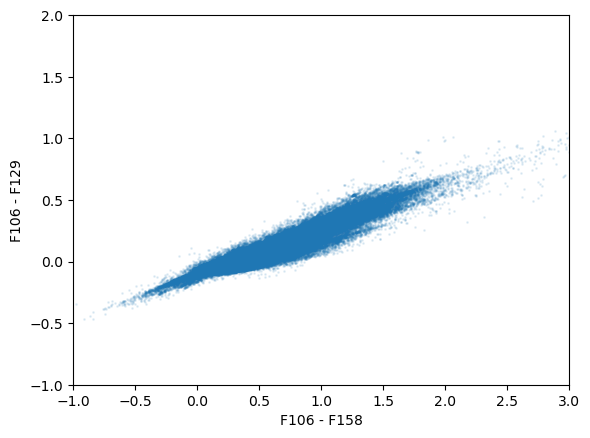

In [39]:
plt.scatter(sim_cat[flag]['MAG_F106'] - sim_cat[flag]['MAG_F158'], 
            sim_cat[flag]['MAG_F106'] - sim_cat[flag]['MAG_F129'], s=1, alpha=0.1)
plt.xlim(-1, 3)
plt.ylim(-1, 2)
plt.xlabel('F106 - F158')
plt.ylabel('F106 - F129')

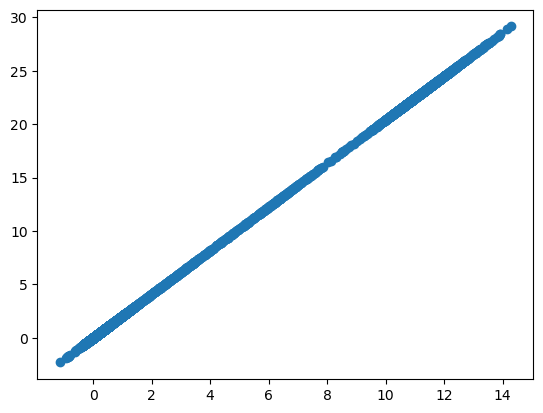

In [15]:
plt.scatter(-2.5 * np.log10(sim_cat['FLUX_F106']/sim_cat['FLUX_F129']), -2.5 * np.log10(sim_cat['FLUX_F106']/sim_cat['FLUX_F158']))

## 2. Artpop and make catalogs for Romanisim

In [4]:
from kuaizi.display import display_single

/home/jiaxuanl/Research/Packages/kuaizi/kuaizi/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [5]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"

import artpop
import rosesim
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

In [6]:
# This is chosen randomly. The MW stars from TRILEGAL are actually around this location.
obs_ra = 150.1049 #270.95
obs_dec = 2.2741 # -0.2

In [7]:
s = 1001 # size of the frame
sky = RomanSky(obs_ra, obs_dec, xy_dim=np.array([s, s]), prefix='sky_jaguar_test')
radius = sky.xy_dim[0] * 0.11 / 3600
sky.obs_time = Time('2025-01-01T00:00:00')
# sky.load_gaia_star(radius=radius)
sky.load_trilegal_star(radius=radius, area=0.2)
sky.load_jaguar_bkg(radius=radius, seed=42)
sky.gen_catalog(include_bkg=True, include_star=True)

Warning -- need to figure out the coefficients between JWST and Roman filters.
193 star sources loaded.
895 background galaxies loaded.


Warning -- need to figure out the coefficients between JWST and Roman filters.
193 star sources loaded.
3782 background galaxies loaded.


In [9]:
import romanisim

In [12]:
from romanisim.l3 import l3_psf
psf = l3_psf('F158')

import galsim
import romanisim
romanisim.parameters.pixel_scale

scale = romanisim.parameters.pixel_scale
nx = ny = (int(5 / scale) // 2) * 2 + 1

img = psf.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely

img /= img.array.sum()


2026-01-25 16:19:43 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2026-01-25 16:19:43 INFO     Creating PSF using galsim


In [18]:
date = Time('2025-01-01T00:00:00')
from galsim import roman
roman.getPSF
import romanisim

In [19]:
# image.wcs.toWorld(image.true_center)

In [ ]:
world_pos 

In [34]:
from galsim import CelestialCoord
import galsim

In [77]:
pos = CelestialCoord(0 * galsim.hours, 10 * galsim.degrees)

In [81]:
galsim_filter_name = romanisim.bandpass.roman2galsim_bandpass['F158']
bandpass = roman.getBandpasses(AB_zeropoint=False)[galsim_filter_name]
sky_level = roman.getSkyLevel(bandpass, 
                              world_pos=pos,
                              exptime=1, date=date.to_datetime())
etomjysr = romanisim.bandpass.etomjysr('F158', sca)

print(sky_level * 0.11**2, 'e-/s/pix')
print(sky_level * 0.11**2 * etomjysr, 'Mjy/sr')

1.1164607407237739 e-/s/pix
0.40379773651168455 Mjy/sr


In [46]:
sca = romanisim.parameters.default_sca
pixscalefrac = 1
etomjysr = romanisim.bandpass.etomjysr('F106', sca) #/ pixscalefrac ** 2

In [ ]:
1e/s = 0.367 Mjy/sr

In [47]:
etomjysr

np.float64(0.36761731642448986)

In [49]:
sky_level * etomjysr

np.float64(17.902898976842284)

In [22]:
roman.thermal_backgrounds

{'R062': 0.0,
 'Z087': 0.0,
 'Y106': 0.0,
 'J129': 0.0,
 'H158': 0.04,
 'F184': 0.17,
 'K213': 4.52,
 'W146': 0.98,
 'SNPrism': 0.0,
 'Grism_0thOrder': 0.0,
 'Grism_1stOrder': 0.0}

In [21]:
roman.thermal_backgrounds[galsim_filter_name]

0.04

0.0

In [153]:
romanisim.bandpass.get_abflux('F158', sca) / romanisim.bandpass.get_abflux('F106', sca)

np.float64(1.0164254632623366)

In [157]:
5.18 * 139

np.float64(26.42813589796296)

In [155]:

sky_level *= (1.0 + roman.stray_light_fraction)
sky = image * 0
image.wcs.makeSkyImage(sky, sky_level)
sky += roman.thermal_backgrounds[galsim_filter_name] * pixscalefrac ** 2

NameError: name 'image' is not defined

In [ ]:
exptime = 642 # HLWAS
sky.observe('F158', exptime=exptime, psf_fov_arcsec=15, nexp=6)
sky.observe('F106', exptime=exptime, psf_fov_arcsec=15, nexp=6)
# sky.observe('F106', exptime=exptime)/
# sky.observe('F129', exptime=exptime)

In [23]:
# dm = rosesim.read_L3_asdf('./F158_10272s.asdf')
# rosesim.utils.asdf_to_fits(dm, 'F158_10272s.fits', subtract_bkg=False)

Successfully wrote FITS file: F158_10272s.fits


Successfully wrote FITS file: F158_10272s.fits


In [67]:
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena')

In [68]:
dm = rosesim.read_L3_asdf('./F158_642s.asdf')
rosesim.utils.asdf_to_fits(dm, 'F158_642s.fits', subtract_bkg=False)

dm = rosesim.read_L3_asdf('./F106_642s.asdf')
rosesim.utils.asdf_to_fits(dm, 'F106_642s.fits', subtract_bkg=False)

Successfully wrote FITS file: F158_642s.fits
Successfully wrote FITS file: F106_642s.fits


In [69]:
dm = rosesim.read_L3_asdf('./F158_5136s.asdf')
rosesim.utils.asdf_to_fits(dm, 'F158_5136s.fits', subtract_bkg=False)

dm = rosesim.read_L3_asdf('./F106_5136s.asdf')
rosesim.utils.asdf_to_fits(dm, 'F106_5136s.fits', subtract_bkg=False)

Successfully wrote FITS file: F158_5136s.fits
Successfully wrote FITS file: F106_5136s.fits


In [46]:
hdu = fits.open('F158_642s.fits')

In [76]:
np.max(hdu[0].data * 642)

np.float32(251556.67)

In [11]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test'

In [111]:
np.std(dm.data)

np.float32(0.015557776)

In [113]:
-2.5 * np.log10(0.023651736 / 0.015557776)

np.float64(-0.4547887713037918)

In [91]:
np.std(dm.data)

np.float32(0.023651736)

In [145]:
sca = romanisim.parameters.default_sca
pixscalefrac = 0.11
etomjysr = romanisim.bandpass.etomjysr('F106', sca) / pixscalefrac ** 2
etomjysr

np.float64(30.38159639871817)

In [146]:
sca = romanisim.parameters.default_sca
pixscalefrac = 0.11
etomjysr = romanisim.bandpass.etomjysr('F158', sca) / pixscalefrac ** 2
etomjysr

np.float64(29.89062897067226)

In [147]:
30.38159639871817 / 29.89062897067226

1.0164254632623366

In [148]:
6.28 / 5.18

1.2123552123552124

In [119]:
2.5 * np.log10(np.sqrt(9.65 / 4.83))

np.float64(0.3757252282403506)

In [122]:
np.sqrt(9.65 / 4.83) * 0.9

np.float64(1.2721332404140928)

In [120]:
10**(0.1 / 2.5)

1.096478196143185

In [142]:
avg_bkg = 3.55 / 39
t = 107

In [143]:
flux_source = (6.19 - 9 * avg_bkg) * t
flux_source

574.6723076923078

In [144]:
flux_source / (np.sqrt(flux_source + 9 * avg_bkg * t))

np.float64(22.329708645553666)

In [85]:
wcs = romanisim.wcs.GWCS(dm.meta.wcs)
pixscalefrac = romanisim.l3.get_pixscalefrac(wcs, dm.data.shape)

2025-12-19 19:44:45 INFO     Setting pixscale to match default.


In [86]:
pixscalefrac

1

In [83]:
dm = rosesim.read_L3_asdf('./F158_642s.asdf')
dm.data.std()

np.float32(0.023651736)

In [82]:
dm = rosesim.read_L3_asdf('./F106_642s.asdf')
dm.data.std()

np.float32(0.023872357)

## 3. Visualize the sky background

In [52]:
from astropy.visualization import make_lupton_rgb

In [73]:
zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


In [49]:
os.chdir('../sky_jaguar_test/')
# os.chdir('../empty_sky/')

In [50]:
filters = ['F106', 'F129', 'F158']
imgs = []
exptime = 642
# exptime = 2568
# exptime = 2568 * 4
for filt in filters:
    af = asdf.open(f'./{filt}_{exptime}s.asdf')
    dm = rdm.open(af)
    img = dm.data - np.median(dm.data)
    img *= 10**(0.4 * (27 - zp))
    imgs.append(img[:, :])

In [53]:
# rgb = make_lupton_rgb(1.0 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=-0.03, stretch=1, Q=4)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=1, Q=3)
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb)
plt.axis('off')

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/sky_jaguar_trilegal_{exptime}s.png', bbox_inches='tight', dpi=200, transparent=True)
# plt.close()

ValueError: The image shapes must match. r: (501, 501), g: (1001, 1001) b: (1001, 1001)

Check https://tigress-web.princeton.edu/~jiaxuanl/figure/SBF/Rosesim/sky.png

---

In [16]:
import romanisim

In [57]:
from romanisim.l3 import l3_psf
psf = l3_psf('F158', 0.1078577405, stpsf=True, fov_arcsec=5)

2025-12-18 21:51:53 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2025-12-18 21:51:53 INFO     Using pupil mask 'F062' and detector 'WFI01'.


2025-12-18 21:51:53 INFO     Using pupil mask 'F062' and detector 'WFI02'.


2025-12-18 21:51:53 INFO     Using pupil mask 'F158' and detector 'WFI02'.


2025-12-18 21:51:53 INFO     No source spectrum supplied, therefore defaulting to 5700 K blackbody


...

2025-12-18 21:52:01 INFO             resulting image peak drops to 0.973 of its previous value


2025-12-18 21:52:01 INFO     Detector charge diffusion not applied because charge_diffusion_sigma option is 0


2025-12-18 21:52:01 INFO      Adding extension with image downsampled to detector pixel scale.


2025-12-18 21:52:01 INFO      Downsampling to detector pixel scale, by 4


2025-12-18 21:52:01 INFO      Downsampling to detector pixel scale, by 4


In [58]:
import galsim
import romanisim
print(romanisim.parameters.pixel_scale)

scale = romanisim.parameters.pixel_scale
nx = ny = (int(5 / scale) // 2) * 2 + 1

img = psf.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
img /= img.array.sum()

0.11


In [60]:
0.1078577405 * 43

4.6378828415

In [59]:
nx

45

In [61]:
img.array.shape[0] * 0.11

4.95

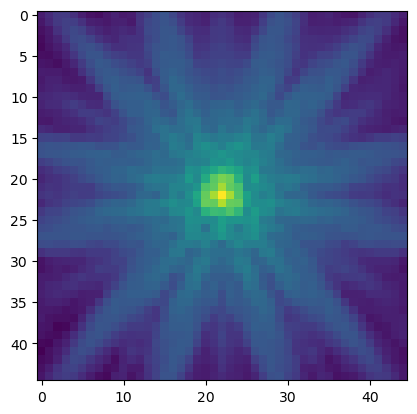

In [62]:
plt.imshow(np.log10(img.array))

In [143]:
dm = rosesim.read_L3_asdf("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar/F158_642s.asdf")

In [144]:
dm.meta

{'association': {'name': '?'}, 'cal_logs': <roman_datamodels.stnode.CalLogs object at 0x7f3ad447dae0>, 'cal_step': {'flux': 'COMPLETE', 'outlier_detection': 'COMPLETE', 'resample': 'COMPLETE', 'skymatch': 'COMPLETE'}, 'calibration_software_name': 'RomanCAL', 'calibration_software_version': '?', 'coadd_info': {'exposure_time': 642.0, 'individual_image_meta': None, 'max_exposure_time': 642.0, 'time_first': <Time object: scale='utc' format='mjd' value=60675.99628472222>, 'time_last': <Time object: scale='utc' format='mjd' value=60676.00371527778>, 'time_mean': <Time object: scale='utc' format='isot' value=2025-01-01T00:00:00.000>}, 'coordinates': {'reference_frame': 'ICRS'}, 'file_date': <FileDate object: scale='utc' format='isot' value=2020-01-01T00:00:00.000>, 'filename': 'F158_642s.asdf', 'individual_image_meta': {}, 'instrument': {'name': 'WFI', 'optical_element': 'F158'}, 'model_type': 'MosaicModel', 'observation': {'execution_plan': -999999, 'exposure': -999999, 'exposure_grouping':

In [22]:
gwcs = dm.meta.wcs

In [25]:
gwcs.footprint()

array([[150.02843971,   2.19769392],
       [150.02843161,   2.35050203],
       [150.18136839,   2.35050203],
       [150.18136029,   2.19769392]])

In [84]:
obs_ra / 15, obs_dec

(10.006993333333332, 2.2741)

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal'